# 04 — Modélisation prédictive (JO 2028)

Objectif : prédire le nombre de médailles par pays pour **Los Angeles 2028**, comparer plusieurs algorithmes et évaluer leur performance.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'config.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Racine projet :', ROOT)

Racine projet : C:\Users\nicol\ynov\Fil Rouge\Projet-Fil-Rouge-J.O


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from src.data.data_loader import load_raw_data
from src.data.data_cleaner import clean_data
from src.models.predictor import predict_medals_2028, get_country_trend
from src.models import evaluator as ev

df = clean_data(load_raw_data())

## Pourquoi filtrer les nations actives ?

Sans filtre, une régression sur l'historique de l'**URSS** (séries longues et croissantes) extrapole un total absurde pour 2028 — alors que ce pays n'existe plus. On ne prédit donc que les nations présentes depuis 2016.

In [3]:
sans_filtre = predict_medals_2028(df, top_n=5, only_active=False)
print('SANS filtre (top 5) :')
print(sans_filtre.to_string())
avec_filtre = predict_medals_2028(df, top_n=5, only_active=True)
print('\nAVEC filtre nations actives (top 5) :')
print(avec_filtre.to_string())

SANS filtre (top 5) :
   NOC           Pays  Médailles prédites 2028
1  URS   Soviet Union                      639
2  USA  United States                      292
3  GER        Germany                      182
4  RUS         Russia                      174
5  CHN          China                      169

AVEC filtre nations actives (top 5) :
   NOC           Pays  Médailles prédites 2028
1  USA  United States                      292
2  GER        Germany                      182
3  RUS         Russia                      174
4  CHN          China                      169
5  AUS      Australia                      126


## Comparaison de modèles sur un pays

Métriques in-sample (MAE, RMSE, R²) pour choisir l'algorithme le plus adapté.

In [4]:
models = {
    'Linéaire': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}
ev.evaluate_models_on_country(df, 'United States', models)

,Modèle,MAE,RMSE,R2,Prédiction 2028
0,Gradient Boosting,2.943738,3.540507,0.998583,319
1,Linéaire,47.951209,71.051510,0.429468,292
2,Ridge,47.951454,71.051510,0.429468,292


## Classement prédit pour 2028

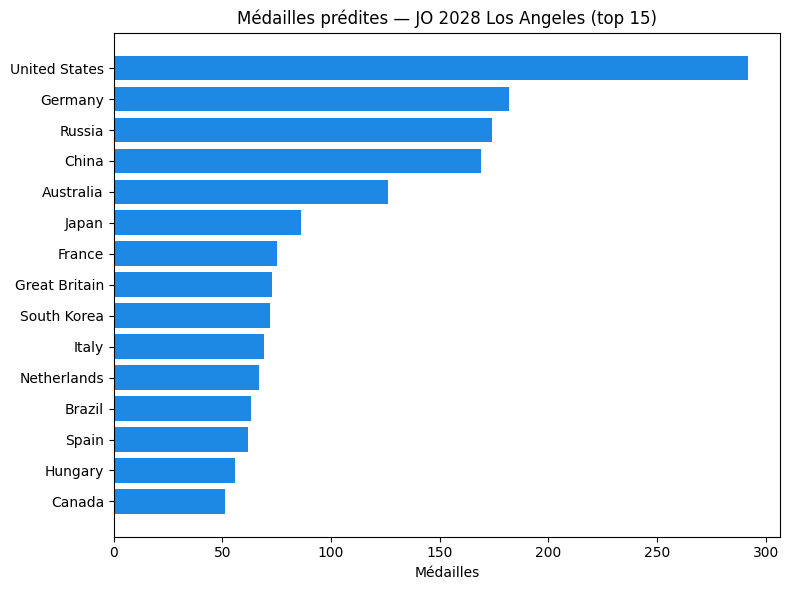

,NOC,Pays,Médailles prédites 2028
1,USA,United States,292
2,GER,Germany,182
3,RUS,Russia,174
4,CHN,China,169
5,AUS,Australia,126
6,JPN,Japan,86
7,FRA,France,75
8,GBR,Great Britain,73
9,KOR,South Korea,72
10,ITA,Italy,69


In [5]:
pred = predict_medals_2028(df, top_n=15)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(pred['Pays'][::-1], pred['Médailles prédites 2028'][::-1], color='#1E88E5')
ax.set_title('Médailles prédites — JO 2028 Los Angeles (top 15)'); ax.set_xlabel('Médailles')
plt.tight_layout(); plt.show()
pred

## Historique et projection d'un pays

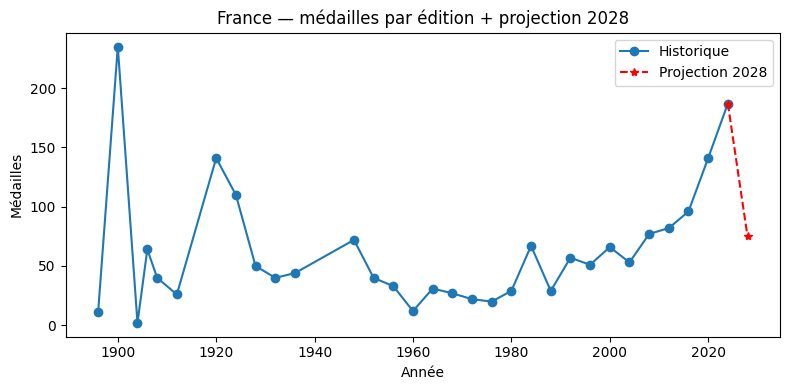

Prédiction France 2028 : 75 médailles


In [6]:
hist, pred_2028 = get_country_trend(df, 'France')
last_y, last_v = int(hist['Year'].iloc[-1]), int(hist['Total'].iloc[-1])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist['Year'], hist['Total'], marker='o', label='Historique')
ax.plot([last_y, 2028], [last_v, pred_2028], '--', marker='*', color='red', label='Projection 2028')
ax.set_title('France — médailles par édition + projection 2028')
ax.set_xlabel('Année'); ax.set_ylabel('Médailles'); ax.legend()
plt.tight_layout(); plt.show()
print('Prédiction France 2028 :', pred_2028, 'médailles')

## Conclusion & limites

- Le filtre **nations actives** rend le classement 2028 crédible (USA, Russie, Allemagne, Chine…).
- Plusieurs modèles comparés via MAE / RMSE / R² ; la régression linéaire reste un bon compromis.
- **Limites** : extrapolation non bornée, pas de prise en compte des nouvelles disciplines ni du contexte géopolitique. Les prédictions sont des **tendances**, pas des certitudes.